In [1]:
!python --version

Python 3.13.12


In [3]:
!nvidia-smi

Tue Apr  7 09:55:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.47                 Driver Version: 572.47         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   45C    P8              1W /   45W |       0MiB /   6141MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, LambdaLR, CosineAnnealingLR

from PIL import Image
from tqdm import tqdm
import os

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import transforms
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection._utils import retrieve_out_channels

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
dataset_path = 'c:\\Auto\\license_plate_OCR\\License-Plate-Recognition-11'

In [10]:
class LicensePlateDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.targets = {}

        print(f"Loading dataset from {root_dir}...")

        for root, dirs, files in os.walk(f"{root_dir}/images"):
            jpg_files = [f for f in files if f.endswith('.jpg')]
            for file in tqdm(jpg_files, desc=f"Loading {os.path.basename(root)}", unit="img"):
                self.image_paths.append(os.path.join(root, file))
                label_path = os.path.join(f"{root_dir}/labels", file.replace('.jpg', '.txt'))
                with open(label_path, 'r') as f:
                    lines = f.readlines()

                    if len(lines) == 0:
                        print(f"Warning: No labels found for {file}. Skipping.")
                        self.image_paths.pop()  # Remove image if no labels
                        continue

                    labels = []
                    bboxes = []
                    for line in lines:
                        parts = line.strip().split()
                        
                        if len(parts) != 5:
                            print(f"Warning: Invalid label format in {label_path}: '{line.strip()}'. Skipping this line.")
                            self.image_paths.pop()  # Remove image if label format is invalid
                            break

                        labels.append(int(parts[0]) + 1)  # +1 to reserve 0 for background
                        cx, cy, w, h = [float(x) for x in parts[1:]]
                        bboxes.append([cx - w/2, cy - h/2, cx + w/2, cy + h/2])
                    self.targets[file] = {'labels': labels, 'boxes': bboxes}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")  
        target = self.targets[os.path.basename(image_path)]

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(target['labels'], dtype=torch.int64)
        boxes = torch.tensor(target['boxes'], dtype=torch.float32)

        return image, boxes, labels

In [11]:
transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
])

In [12]:
train_dataset = LicensePlateDataset(root_dir=dataset_path + "/train", transform=transform)
valid_dataset = LicensePlateDataset(root_dir=dataset_path + "/valid", transform=transform)
test_dataset  = LicensePlateDataset(root_dir=dataset_path + "/test", transform=transform)

Loading dataset from c:\Auto\license_plate_OCR\License-Plate-Recognition-11/train...


Loading images:   3%|▎         | 246/7057 [00:02<00:59, 114.15img/s]

Loading images:  62%|██████▏   | 4368/7057 [00:38<00:23, 115.45img/s]

Loading images:  63%|██████▎   | 4418/7057 [00:38<00:23, 112.67img/s]

Loading images:  64%|██████▍   | 4514/7057 [00:39<00:22, 110.84img/s]

...

Loading images:  71%|███████▏  | 1463/2048 [00:12<00:04, 117.73img/s]

Loading images: 100%|██████████| 2048/2048 [00:18<00:00, 113.52img/s]


Loading dataset from c:\Auto\license_plate_OCR\License-Plate-Recognition-11/test...


Loading images:  65%|██████▍   | 659/1020 [00:05<00:03, 119.43img/s]

Loading images: 100%|██████████| 1020/1020 [00:08<00:00, 114.44img/s]


In [13]:
def collate_fn(batch):
    images, boxes, labels = zip(*batch)
    images = torch.stack(images, 0)

    max_boxes = max(b.shape[0] for b in boxes)

    padded_boxes = torch.zeros(len(boxes), max_boxes, 4)
    padded_labels = torch.full((len(labels), max_boxes), -1, dtype=torch.int64)  # -1 = padding

    for i, (b, l) in enumerate(zip(boxes, labels)):
        num = b.shape[0]
        padded_boxes[i, :num] = b
        padded_labels[i, :num] = l

    return images, padded_boxes, padded_labels

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, collate_fn=collate_fn)

Batch images shape: torch.Size([16, 3, 320, 320])
Batch boxes shape: torch.Size([16, 1, 4])
Batch labels shape: torch.Size([16, 1])


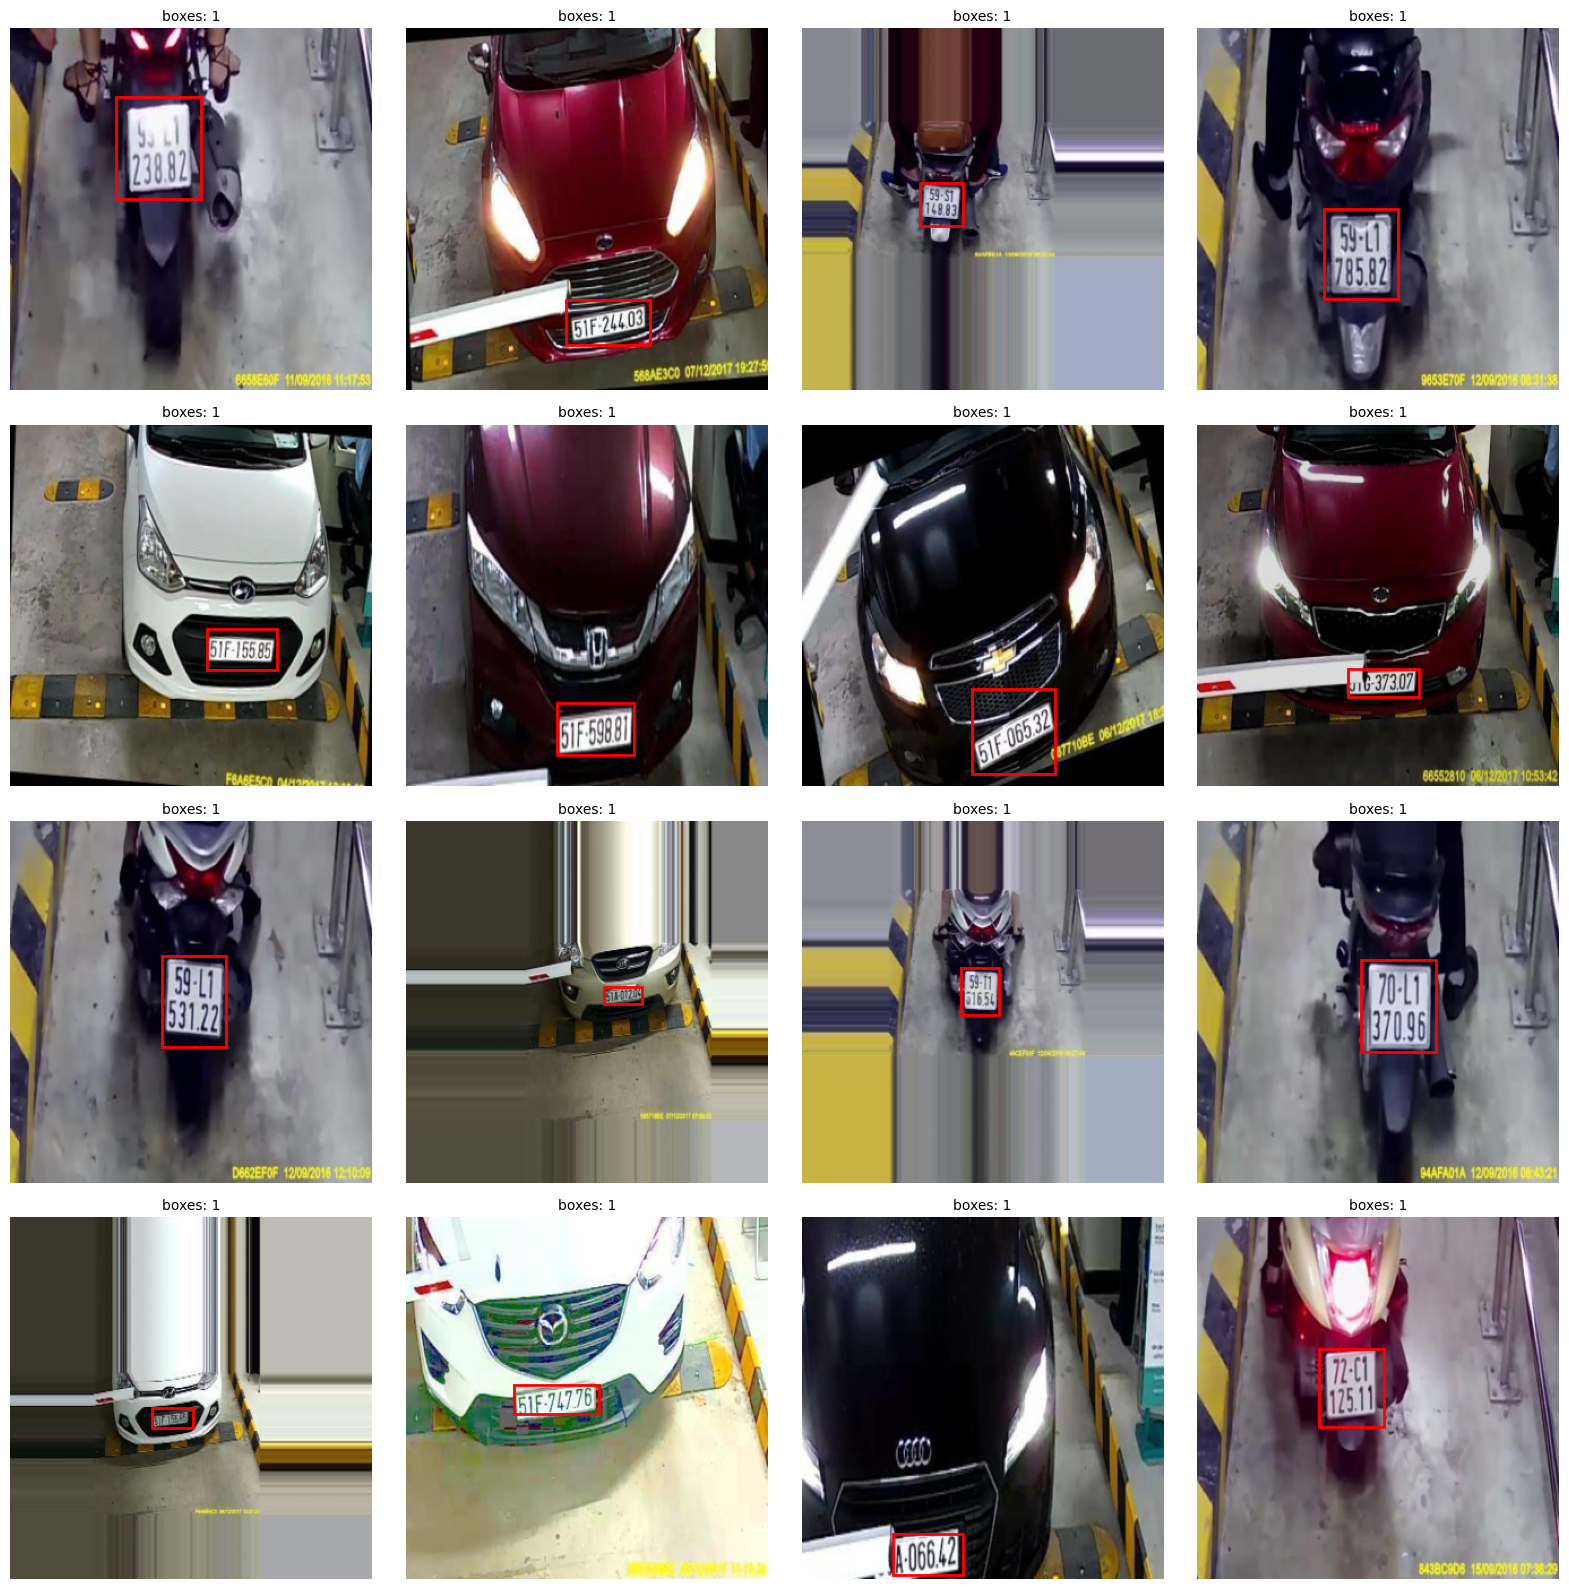

In [10]:
for images, boxes, labels in train_loader:
    print(f"Batch images shape: {images.shape}")
    print(f"Batch boxes shape: {boxes.shape}")
    print(f"Batch labels shape: {labels.shape}")

    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes = axes.flatten()

    for i in range(16):
        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        h, w = img.shape[:2]

        axes[i].imshow(img)
        axes[i].axis('off')

        for box in boxes[i]:
            x_min, y_min, x_max, y_max = box.tolist()
            x_min, x_max = x_min * w, x_max * w
            y_min, y_max = y_min * h, y_max * h
            rect = patches.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            axes[i].add_patch(rect)
            axes[i].set_title(f"boxes: {(labels[i] != -1).sum().item()}", fontsize=10)

    plt.tight_layout()
    plt.show()
    break

In [11]:
model = ssdlite320_mobilenet_v3_large(weights=SSDLite320_MobileNet_V3_Large_Weights.DEFAULT)
in_channels = retrieve_out_channels(model.backbone, (320, 320))
num_anchors = model.anchor_generator.num_anchors_per_location()
num_classes = 2 # background + license plate
model.head.classification_head = SSDClassificationHead(
    in_channels, 
    num_anchors, 
    num_classes
)
model.transform.min_size = (320, )
model.transform.max_size = 320
model.to(device)

SSD(
  (backbone): SSDLiteFeatureExtractorMobileNet(
    (features): Sequential(
      (0): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (2): Hardswish()
        )
        (1): InvertedResidual(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
              (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
            )
            (1): Conv2dNormActivation(
              (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (1): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
            )
          )
        )
        (2): Invert

In [43]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

def evaluate(model, loader, device):
    model.eval()

    metric = MeanAveragePrecision(
        iou_type="bbox",
        max_detection_thresholds=[1, 10, 300]
    )
    metric.warn_on_many_detections = False

    total_time = 0.0
    total_images = 0

    starter = torch.cuda.Event(enable_timing=True)
    ender   = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for images, boxes, labels in tqdm(loader, desc="Evaluating", unit="batch"):
            images = [img.to(device) for img in images]
            batch_size = len(images)

            # ===== GPU timing (forward only) =====
            starter.record()
            outputs = model(images)
            ender.record()

            torch.cuda.synchronize()
            elapsed_ms = starter.elapsed_time(ender)

            total_time += elapsed_ms
            total_images += batch_size

            # ===== metric processing =====
            preds = []
            targets = []

            for i in range(batch_size):
                keep = outputs[i]['scores'] > 0.3

                preds.append({
                    'boxes':  outputs[i]['boxes'][keep].cpu(),
                    'scores': outputs[i]['scores'][keep].cpu(),
                    'labels': outputs[i]['labels'][keep].cpu(),
                })

                mask = labels[i] != -1
                targets.append({
                    'boxes':  boxes[i][mask].cpu() * 320,
                    'labels': labels[i][mask].cpu(),
                })

            metric.update(preds, targets)

    results = metric.compute()

    # ===== Performance stats =====
    avg_ms_per_image = total_time / total_images
    fps = 1000.0 / avg_ms_per_image

    print(f"\n🚀 Avg inference time: {avg_ms_per_image:.2f} ms/image")
    print(f"🚀 FPS: {fps:.2f}")

    return results

In [14]:
print("=== Base model (no training) ===")
results = evaluate(model, test_loader, device)
results

=== Base model (no training) ===


Evaluating: 100%|██████████| 64/64 [00:11<00:00,  5.71batch/s]


mAP@0.50:      0.0058
mAP@0.50:0.95: -1.0000


{'map': tensor(-1.),
 'map_50': tensor(0.0058),
 'map_75': tensor(0.0002),
 'map_small': tensor(9.4949e-06),
 'map_medium': tensor(0.0019),
 'map_large': tensor(0.0020),
 'mar_1': tensor(0.0062),
 'mar_10': tensor(0.0476),
 'mar_300': tensor(0.2079),
 'mar_small': tensor(0.0085),
 'mar_medium': tensor(0.2552),
 'mar_large': tensor(0.4516),
 'map_per_class': tensor(-1.),
 'mar_300_per_class': tensor(-1.),
 'classes': tensor(1, dtype=torch.int32)}

In [6]:
def get_base_model(num_classes, size=(320, 320)):
    model = ssdlite320_mobilenet_v3_large(weights=SSDLite320_MobileNet_V3_Large_Weights.DEFAULT)
    in_channels = retrieve_out_channels(model.backbone, size)
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head.classification_head = SSDClassificationHead(
        in_channels, 
        num_anchors, 
        num_classes
    )
    model.transform.min_size = (size[0], )
    model.transform.max_size = size[0]
    return model

def find_lr(model, loader, device, start_lr=1e-7, end_lr=1, num_iter=100, smoothing=0.05):
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=start_lr
    )

    mult = (end_lr / start_lr) ** (1 / num_iter)
    scheduler = LambdaLR(optimizer, lambda step: mult ** step)

    lrs, losses = [], []
    best_loss = float('inf')
    avg_loss = 0

    model.train()
    data_iter = iter(loader)

    for step in tqdm(range(num_iter), desc="Finding LR", unit="step"):
        try:
            images, boxes, labels = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            images, boxes, labels = next(data_iter)

        images = [img.to(device) for img in images]
        targets = []
        for i in range(len(images)):
            mask = labels[i] != -1
            targets.append({
                'boxes':  boxes[i][mask].to(device) * 320,
                'labels': labels[i][mask].to(device)
            })

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        # smooth loss
        avg_loss = smoothing * loss.item() + (1 - smoothing) * avg_loss
        smoothed = avg_loss / (1 - (1 - smoothing) ** (step + 1))

        # stop if loss explodes
        if step > 0 and smoothed > 4 * best_loss:
            print(f"Loss exploded at step {step}, stopping early.")
            break

        if smoothed < best_loss:
            best_loss = smoothed

        lrs.append(optimizer.param_groups[0]['lr'])
        losses.append(smoothed)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

    # plot
    plt.figure(figsize=(10, 5))
    plt.plot(lrs, losses)
    plt.xscale('log')
    plt.xlabel('Learning Rate (log scale)')
    plt.ylabel('Smoothed Loss')
    plt.title('LR Finder')
    plt.grid(True)

    min_idx = losses.index(min(losses))
    best_lr = lrs[min_idx]
    suggested_lr = lrs[max(0, min_idx - 5)]  # slightly left of minimum = steepest descent

    plt.axvline(x=best_lr,      color='red',    linestyle='--', label=f'Min loss: {best_lr:.2e}')
    plt.axvline(x=suggested_lr, color='green',  linestyle='--', label=f'Suggested: {suggested_lr:.2e}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Min loss lr:  {best_lr:.2e}")
    print(f"Suggested lr: {suggested_lr:.2e}  ← use this")
    return suggested_lr

Finding LR:  86%|████████▌ | 86/100 [00:17<00:02,  4.99step/s]


Loss exploded at step 86, stopping early.


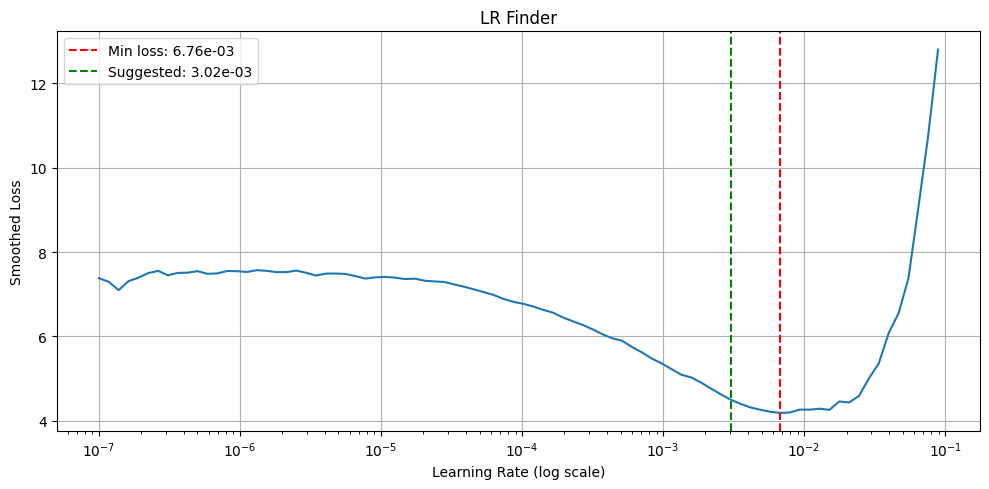

Min loss lr:  6.76e-03
Suggested lr: 3.02e-03  ← use this
Using learning rate: 3.02e-03


In [14]:
# Fine-tune the backbone with a low learning rate

model = get_base_model(num_classes=2).to(device)
for param in model.backbone.parameters():
    param.requires_grad = True

learning_rate = find_lr(model, train_loader, device)
print(f"Using learning rate: {learning_rate:.2e}")

In [16]:
model = get_base_model(num_classes=2).to(device)
for param in model.backbone.parameters():
    param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=1e-4
)
epochs = 50
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=learning_rate/100)

train_losses = []
val_map50s   = []
best_map50   = 0.0

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")

    # ── train ────────────────────────────────────────────
    model.train()
    train_loss = 0

    for images, boxes, labels in tqdm(train_loader, desc="Training", unit="batch"):
        images = [img.to(device) for img in images]
        targets = []
        for i in range(len(images)):
            mask = labels[i] != -1
            targets.append({
                'boxes':  boxes[i][mask].to(device) * 320,
                'labels': labels[i][mask].to(device)
            })

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    scheduler.step()

    results  = evaluate(model, valid_loader, device)
    map50    = results['map_50'].item()
    val_map50s.append(map50)

    print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {train_loss:.4f} | Val mAP@50: {map50:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    if map50 > best_map50:
        best_map50 = map50
        torch.save(model.state_dict(), f"./model/best_finetune.pth")
        print(f"  - Saved best model (mAP@50={best_map50:.4f})")

    torch.save(model.state_dict(), f"./model/last_finetune.pth")

Epoch 1/50


Evaluating: 100%|██████████| 128/128 [00:19<00:00,  6.54batch/s]


Epoch 001/50 | Train Loss: 2.2415 | Val mAP@50: 0.7798 | LR: 3.02e-03
  - Saved best model (mAP@50=0.7798)
Epoch 2/50


Evaluating: 100%|██████████| 128/128 [00:19<00:00,  6.50batch/s]


Epoch 002/50 | Train Loss: 1.7130 | Val mAP@50: 0.6399 | LR: 3.01e-03
Epoch 3/50


...

Epoch 047/50 | Train Loss: 0.1409 | Val mAP@50: 0.7749 | LR: 5.67e-05
Epoch 48/50


Evaluating: 100%|██████████| 128/128 [00:19<00:00,  6.59batch/s]


Epoch 048/50 | Train Loss: 0.1330 | Val mAP@50: 0.7755 | LR: 4.20e-05
Epoch 49/50


Training:  10%|▉         | 42/441 [00:08<01:22,  4.82batch/s]


KeyboardInterrupt: 

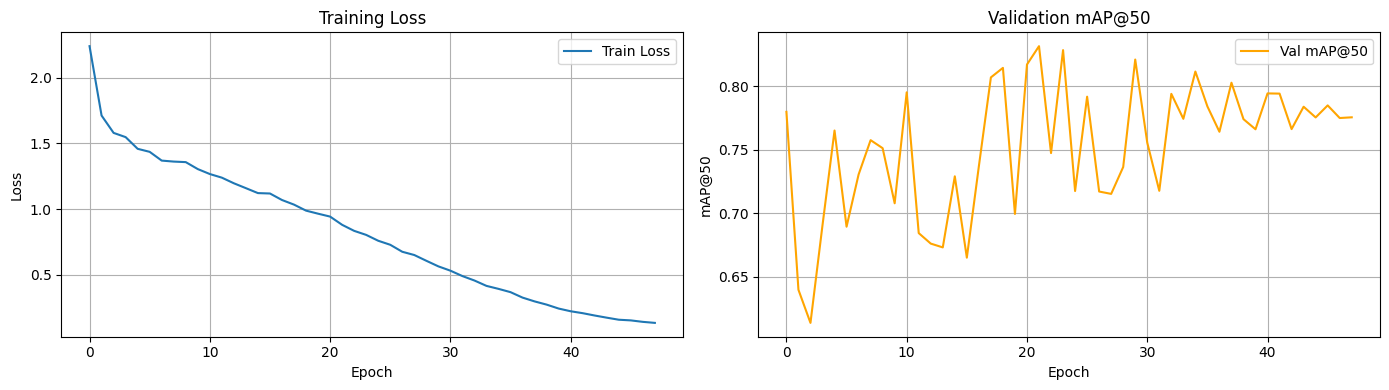

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(val_map50s, label='Val mAP@50', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mAP@50')
ax2.set_title('Validation mAP@50')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [49]:
def predict(model, image_path, device, score_threshold=0.3):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).to(device)

    model.eval()

    starter = torch.cuda.Event(enable_timing=True)
    ender   = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        _ = model([image_tensor])

    starter.record()
    with torch.no_grad():
        output = model([image_tensor])[0]
    ender.record()

    torch.cuda.synchronize()  
    inference_ms = starter.elapsed_time(ender)

    print(f"Inference time: {inference_ms:.2f} ms  ({1000/inference_ms:.1f} FPS)")

    keep   = output['scores'] > score_threshold
    boxes  = output['boxes'][keep].cpu()
    labels = output['labels'][keep].cpu()
    scores = output['scores'][keep].cpu()

    print(f"Detected: {len(boxes)} license plate(s)")
    for i, (box, score) in enumerate(zip(boxes, scores)):
        print(f"  [{i+1}] score={score:.4f} | box={box.tolist()}")

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.imshow(image)
    ax.axis('off')

    orig_w, orig_h = image.size
    scale_x = orig_w / 320
    scale_y = orig_h / 320

    for box, score in zip(boxes, scores):
        x_min, y_min, x_max, y_max = box.tolist()
        x_min *= scale_x;  x_max *= scale_x
        y_min *= scale_y;  y_max *= scale_y

        rect = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x_min, y_min - 5,
            f"plate {score:.2f}",
            color='red', fontsize=11, fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

    return boxes, labels, scores, inference_ms

In [48]:
best_transfer_model = torch.load("./model/last_finetune.pth")
model.load_state_dict(best_transfer_model)
model.to(device)

print("=== Best transfer model ===")
results = evaluate(model, test_loader, device)
results

=== Best transfer model ===


Evaluating: 100%|██████████| 64/64 [00:10<00:00,  6.02batch/s]



🚀 Avg inference time: 5.29 ms/image
🚀 FPS: 189.02


{'map': tensor(-1.),
 'map_50': tensor(0.7950),
 'map_75': tensor(0.5752),
 'map_small': tensor(0.0956),
 'map_medium': tensor(0.6097),
 'map_large': tensor(0.6625),
 'mar_1': tensor(0.5490),
 'mar_10': tensor(0.5545),
 'mar_300': tensor(0.5545),
 'mar_small': tensor(0.1564),
 'mar_medium': tensor(0.6743),
 'mar_large': tensor(0.7391),
 'map_per_class': tensor(-1.),
 'mar_300_per_class': tensor(-1.),
 'classes': tensor(1, dtype=torch.int32)}

Inference time: 22.09 ms  (45.3 FPS)
Detected: 1 license plate(s)
  [1] score=1.0000 | box=[169.3939208984375, 25.47195053100586, 243.3170166015625, 100.00201416015625]


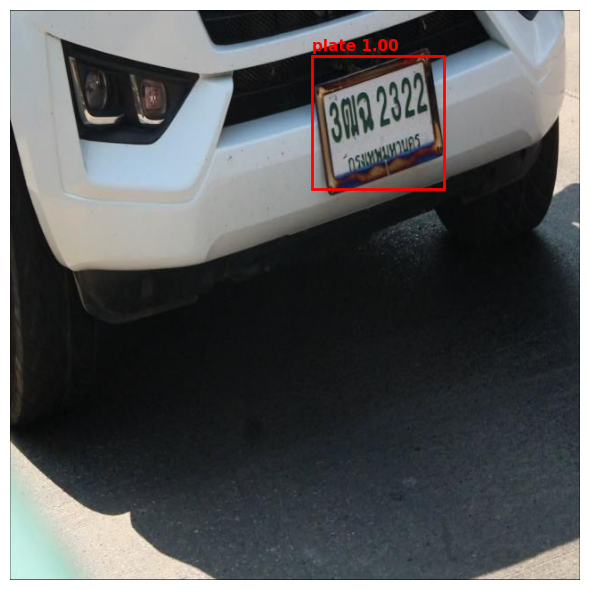

In [50]:
boxes, labels, scores, ms = predict(model, r"thai-license-plate-2\valid\images\Layer-2_png.rf.483fa8ff1258eb8db694befbb7fd9a4f.jpg", device, score_threshold=0.3)

In [45]:
best_transfer_model = torch.load("./model/best_finetune.pth")
model.load_state_dict(best_transfer_model)
model.to(device)

print("=== Best transfer model ===")
results = evaluate(model, test_loader, device)
results

=== Best transfer model ===


Evaluating: 100%|██████████| 64/64 [00:10<00:00,  6.24batch/s]



🚀 Avg inference time: 5.12 ms/image
🚀 FPS: 195.29


{'map': tensor(-1.),
 'map_50': tensor(0.8416),
 'map_75': tensor(0.6166),
 'map_small': tensor(0.1386),
 'map_medium': tensor(0.6492),
 'map_large': tensor(0.6273),
 'mar_1': tensor(0.5740),
 'mar_10': tensor(0.5847),
 'mar_300': tensor(0.5847),
 'mar_small': tensor(0.2259),
 'mar_medium': tensor(0.6965),
 'mar_large': tensor(0.7063),
 'map_per_class': tensor(-1.),
 'mar_300_per_class': tensor(-1.),
 'classes': tensor(1, dtype=torch.int32)}

Inference time: 23.07 ms  (43.3 FPS)
Detected: 1 license plate(s)
  [1] score=0.7088 | box=[126.75293731689453, 189.90383911132812, 177.955810546875, 230.65826416015625]


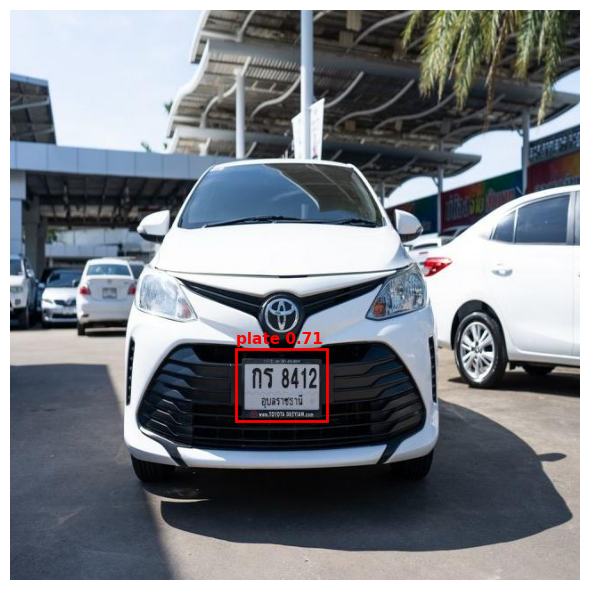

In [47]:
boxes, labels, scores, ms = predict(
    model, 
    r"thai-license-plate-2\valid\images\318613662_8749297468421251_6703461530410607566_n_jpg.rf.6511f4e4732681da75b4d61752ce67dd.jpg", 
    device, 
    score_threshold=0.3
)

In [21]:
model = get_base_model(num_classes=2)
best_transfer_model = torch.load("./model/best_finetune.pth")
model.load_state_dict(best_transfer_model)
model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Frozen params:    {frozen_params:,}")

for name, module in [("backbone", model.backbone), 
                     ("head",     model.head), 
                     ("anchor_generator", model.anchor_generator)]:
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name}: {params:,}")

Total params:     2,402,360
Trainable params: 2,402,360
Frozen params:    0
  backbone: 2,072,672
  head: 329,688
  anchor_generator: 0


In [22]:
import torchvision.ops as ops
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm
import torch
import time

def evaluate_fair(model, loader, device,
                  score_threshold=0.01,   # ultralytics uses 0.001, start with 0.01
                  nms_iou_threshold=0.45, # ultralytics default NMS IoU
                  image_size=320):
    model.eval()

    metric = MeanAveragePrecision(
        iou_type="bbox",
        max_detection_thresholds=[1, 10, 300]
    )
    metric.warn_on_many_detections = False

    total_inference_ms  = 0.0
    total_preprocess_ms = 0.0
    total_postprocess_ms = 0.0
    total_images = 0

    starter = torch.cuda.Event(enable_timing=True)
    ender   = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for images, boxes, labels in tqdm(loader, desc="Evaluating", unit="batch"):
            batch_size = len(images)

            # ── preprocess (match ultralytics: normalize to [0,1], resize already done) ──
            t0 = time.perf_counter()
            images_gpu = [img.to(device) for img in images]
            total_preprocess_ms += (time.perf_counter() - t0) * 1000

            # ── inference ────────────────────────────────────────────────────────────────
            starter.record()
            outputs = model(images_gpu)
            ender.record()
            torch.cuda.synchronize()
            total_inference_ms += starter.elapsed_time(ender)

            # ── postprocess: score filter + NMS (ultralytics does this too) ─────────────
            t1 = time.perf_counter()
            preds   = []
            targets = []

            for i in range(batch_size):
                boxes_pred  = outputs[i]['boxes']
                scores_pred = outputs[i]['scores']
                labels_pred = outputs[i]['labels']

                # step 1 — score threshold (low like ultralytics, NMS handles the rest)
                keep = scores_pred > score_threshold
                boxes_pred  = boxes_pred[keep]
                scores_pred = scores_pred[keep]
                labels_pred = labels_pred[keep]

                # step 2 — NMS per class (ultralytics uses class-aware NMS)
                if len(boxes_pred) > 0:
                    keep_nms = ops.batched_nms(
                        boxes_pred, scores_pred, labels_pred, nms_iou_threshold
                    )
                    boxes_pred  = boxes_pred[keep_nms]
                    scores_pred = scores_pred[keep_nms]
                    labels_pred = labels_pred[keep_nms]

                preds.append({
                    'boxes':  boxes_pred.cpu(),
                    'scores': scores_pred.cpu(),
                    'labels': labels_pred.cpu(),
                })

                # ground truth — denormalize from [0,1] to pixel coords
                mask = labels[i] != -1
                targets.append({
                    'boxes':  boxes[i][mask].cpu() * image_size,
                    'labels': labels[i][mask].cpu(),
                })

            total_postprocess_ms += (time.perf_counter() - t1) * 1000
            total_images += batch_size

            metric.update(preds, targets)

    results = metric.compute()

    # ── per-image timing (matches ultralytics speed dict) ────────────────────────
    pre_ms   = total_preprocess_ms  / total_images
    inf_ms   = total_inference_ms   / total_images
    post_ms  = total_postprocess_ms / total_images
    total_ms = pre_ms + inf_ms + post_ms

    print(f"\nmAP@50:      {results['map_50']:.4f}")
    print(f"mAP@50-95:   {results['map']:.4f}")
    print(f"mar_300:     {results['mar_300']:.4f}")
    print(f"\nSpeed (per image):")
    print(f"  preprocess:  {pre_ms:.2f}ms")
    print(f"  inference:   {inf_ms:.2f}ms")
    print(f"  postprocess: {post_ms:.2f}ms")
    print(f"  total:       {total_ms:.2f}ms  ({1000/total_ms:.1f} FPS)")

    return results, {
        "mAP50":          results['map_50'].item(),
        "mAP50-95":       results['map'].item(),
        "mar_300":        results['mar_300'].item(),
        "preprocess_ms":  round(pre_ms, 2),
        "inference_ms":   round(inf_ms, 2),
        "postprocess_ms": round(post_ms, 2),
    }

def warmup(model, device, imgsz=320, n=3):
    print(f"Warming up model ({n} iterations)...")
    model.eval()
    dummy = torch.zeros(1, 3, imgsz, imgsz).to(device)
    with torch.no_grad():
        for _ in range(n):
            _ = model([dummy.squeeze(0)])  # SSD expects list of tensors
    torch.cuda.synchronize()
    print("Warmup done.")

warmup(model, device, n=100)
results, summary = evaluate_fair(model, test_loader, device)

Warming up model (100 iterations)...
Warmup done.


Evaluating: 100%|██████████| 64/64 [00:11<00:00,  5.78batch/s]



mAP@50:      0.8707
mAP@50-95:   -1.0000
mar_300:     0.6087

Speed (per image):
  preprocess:  0.29ms
  inference:   5.24ms
  postprocess: 1.12ms
  total:       6.65ms  (150.3 FPS)
